In [1]:
from google.colab import drive

drive.mount('/content/drive')

import os
plant_village_path = '/content/drive/MyDrive/PlantVillage'

if os.path.exists(plant_village_path):
    print(f'成功找到資料夾：{plant_village_path}')
else:
    print(f'已掛載 Drive，但未在 {plant_village_path} 找到資料夾，請檢查路徑。')

Mounted at /content/drive
成功找到資料夾：/content/drive/MyDrive/PlantVillage


In [9]:
import os
import shutil
import splitfolders

# 設定路徑
input_folder = plant_village_path
output_folder = '/content/dataset_split'

# 徹底清理舊的輸出資料夾
if os.path.exists(output_folder):
    print(f"正在清理舊的輸出資料夾: {output_folder}...")
    shutil.rmtree(output_folder)

print("正在開始重新切分資料...")

# 執行資料切分：Train (80%), Val (10%), Test (10%)
# 使用 seed=42 確保每次切分結果一致
splitfolders.ratio(input_folder,
                   output=output_folder,
                   seed=42,
                   ratio=(.8, .1, .1),
                   group_prefix=None,
                   move=False)

print("\n資料切分完畢！開始計算各資料集數量：")

# 驗證切分後的圖片總數
summary = {}
total_count = 0
for split in ['train', 'val', 'test']:
    split_path = os.path.join(output_folder, split)
    count = sum([len(files) for r, d, files in os.walk(split_path) if any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in files)])
    summary[split] = count
    total_count += count
    print(f" - {split} 集合: {count} 張圖片")

print(f"\n總計切分圖片數: {total_count}")

正在清理舊的輸出資料夾: /content/dataset_split...
正在開始重新切分資料...


Copying files: 20639 files [02:56, 116.95 files/s]



資料切分完畢！開始計算各資料集數量：
 - train 集合: 16505 張圖片
 - val 集合: 2058 張圖片
 - test 集合: 2076 張圖片

總計切分圖片數: 20639


In [11]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

# 設定參數
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# 定義轉換流程 (Resize + ToTensor 自動處理正規化 [0, 1])
data_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
])

# 讀取資料集
image_datasets = {
    'train': datasets.ImageFolder(os.path.join(output_folder, 'train'), data_transforms),
    'val': datasets.ImageFolder(os.path.join(output_folder, 'val'), data_transforms),
    'test': datasets.ImageFolder(os.path.join(output_folder, 'test'), data_transforms)
}

# 建立 DataLoader
dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=BATCH_SIZE, shuffle=True, num_workers=2),
    'val': DataLoader(image_datasets['val'], batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
    'test': DataLoader(image_datasets['test'], batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
}

# 輸出資訊確認
print("PyTorch 影像預處理完成：")
print(f" - 圖片尺寸: {IMG_SIZE}")
print(f" - 訓練集數量: {len(image_datasets['train'])}")
print(f" - 驗證集數量: {len(image_datasets['val'])}")
print(f" - 測試集數量: {len(image_datasets['test'])}")
print(f" - 類別總數: {len(image_datasets['train'].classes)}")

PyTorch 影像預處理完成：
 - 圖片尺寸: (224, 224)
 - 訓練集數量: 16504
 - 驗證集數量: 2058
 - 測試集數量: 2076
 - 類別總數: 15


In [12]:
# 建立 DataLoaders
# train 需要 shuffle=True 以增加模型泛化能力
# val 與 test 則不需要打亂

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=BATCH_SIZE, shuffle=True, num_workers=2),
    'val': DataLoader(image_datasets['val'], batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
    'test': DataLoader(image_datasets['test'], batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
}

# 檢查一個 batch 的數據形狀
inputs, classes = next(iter(dataloaders['train']))
print(f"Batch 數據形狀: {inputs.shape}  # [Batch, Channels, Height, Width]")
print(f"Batch 標籤數量: {len(classes)}")
print("DataLoaders 建立完成！")

Batch 數據形狀: torch.Size([32, 3, 224, 224])  # [Batch, Channels, Height, Width]
Batch 標籤數量: 32
DataLoaders 建立完成！


In [13]:
import torch.nn as nn
from torchvision import models

# 取得類別數量
num_classes = len(image_datasets['train'].classes)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(f"正在載入預訓練的 ResNet-18 模型... (目標類別數: {num_classes})")
print(f"使用設備: {device}")

# 載入預訓練模型 (ResNet18)
model_ft = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 凍結所有模型參數 (選擇性，若要全面微調可註解掉下面兩行)
for param in model_ft.parameters():
    param.requires_grad = False

# 修改最後的全連接層 (Fully Connected Layer)
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, num_classes)

# 將模型搬移至 GPU (如果可用)
model_ft = model_ft.to(device)

print("模型定義完成！")
print(model_ft.fc)

正在載入預訓練的 ResNet-18 模型... (目標類別數: 15)
使用設備: cuda:0
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 133MB/s]


模型定義完成！
Linear(in_features=512, out_features=15, bias=True)


In [14]:
import torch.optim as optim

# 設定損失函數 (多分類問題)
criterion = nn.CrossEntropyLoss()

# 設定優化器 (Optimizer)
# 只優化需要梯度的參數 (因為我們先前凍結了特徵提取層，僅對最後一層 fc 進行優化)
optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, model_ft.parameters()), lr=0.001)

print("損失函數與優化器設定完成：")
print(f" - Loss Function: {criterion}")
print(f" - Optimizer: {optimizer_ft}")

損失函數與優化器設定完成：
 - Loss Function: CrossEntropyLoss()
 - Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [15]:
import time
import copy

def train_model(model, criterion, optimizer, num_epochs=10):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # 每個 epoch 都有訓練與驗證階段
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # 設定為訓練模式
            else:
                model.eval()   # 設定為評估模式

            running_loss = 0.0
            running_corrects = 0

            # 迭代資料
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # 歸零參數梯度
                optimizer.zero_grad()

                # 前向傳播 (Forward)
                # 只有在訓練階段才追蹤梯度歷史
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # 只有在訓練階段才執行後向傳播與優化
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # 統計損失與準確率
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc = running_corrects.double() / len(image_datasets[phase])

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # 深拷貝最佳模型權重
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'訓練完成，耗時 {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'最佳驗證集準確度: {best_acc:4f}')

    # 載入最佳模型權重
    model.load_state_dict(best_model_wts)
    return model

# 開始訓練 (先跑 5-10 個 Epochs 看看效果)
model_ft = train_model(model_ft, criterion, optimizer_ft, num_epochs=10)

Epoch 0/9
----------
train Loss: 0.8252 Acc: 0.7860
val Loss: 0.3961 Acc: 0.8980

Epoch 1/9
----------
train Loss: 0.3775 Acc: 0.8915
val Loss: 0.2924 Acc: 0.9164

Epoch 2/9
----------
train Loss: 0.2985 Acc: 0.9123
val Loss: 0.2542 Acc: 0.9223

Epoch 3/9
----------
train Loss: 0.2602 Acc: 0.9195
val Loss: 0.2404 Acc: 0.9310

Epoch 4/9
----------
train Loss: 0.2438 Acc: 0.9249
val Loss: 0.2198 Acc: 0.9295

Epoch 5/9
----------
train Loss: 0.2238 Acc: 0.9303
val Loss: 0.2063 Acc: 0.9359

Epoch 6/9
----------
train Loss: 0.2122 Acc: 0.9318
val Loss: 0.1941 Acc: 0.9407

Epoch 7/9
----------
train Loss: 0.1971 Acc: 0.9360
val Loss: 0.1916 Acc: 0.9383

Epoch 8/9
----------
train Loss: 0.1946 Acc: 0.9360
val Loss: 0.1932 Acc: 0.9373

Epoch 9/9
----------
train Loss: 0.1804 Acc: 0.9433
val Loss: 0.1867 Acc: 0.9417

訓練完成，耗時 7m 57s
最佳驗證集準確度: 0.941691


正在測試集上進行評估...


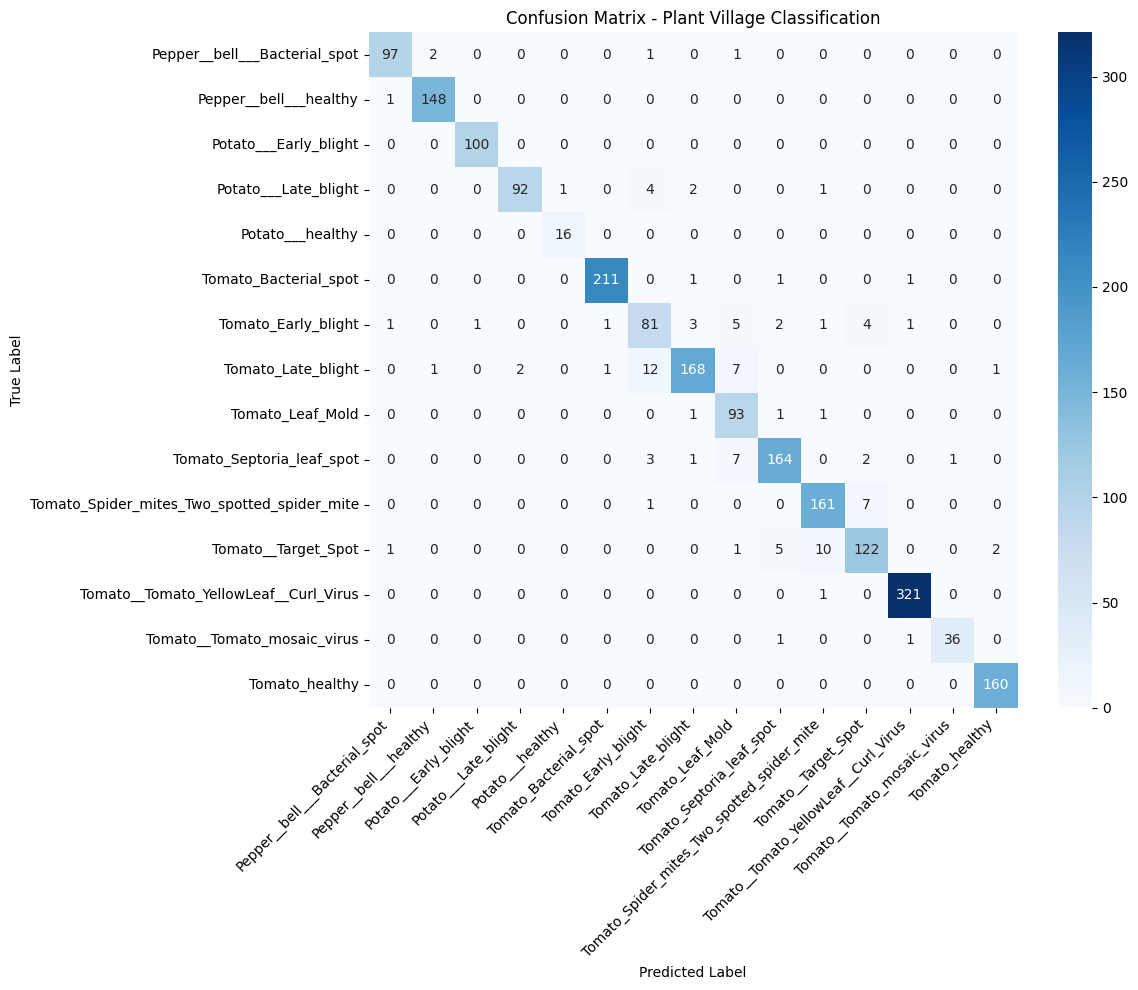


分類報告：
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.97      0.96      0.97       101
                     Pepper__bell___healthy       0.98      0.99      0.99       149
                      Potato___Early_blight       0.99      1.00      1.00       100
                       Potato___Late_blight       0.98      0.92      0.95       100
                           Potato___healthy       0.94      1.00      0.97        16
                      Tomato_Bacterial_spot       0.99      0.99      0.99       214
                        Tomato_Early_blight       0.79      0.81      0.80       100
                         Tomato_Late_blight       0.95      0.88      0.91       192
                           Tomato_Leaf_Mold       0.82      0.97      0.89        96
                  Tomato_Septoria_leaf_spot       0.94      0.92      0.93       178
Tomato_Spider_mites_Two_spotted_spider_mite       0.92   

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. 執行測試集評估並收集預測值
model_ft.eval()
all_preds = []
all_labels = []

print("正在測試集上進行評估...")
with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_ft(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 2. 計算混淆矩陣
class_names = image_datasets['train'].classes
cm = confusion_matrix(all_labels, all_preds)

# 3. 繪製混淆矩陣圖表
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Plant Village Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 4. 輸出分類報告 (F1-score, Precision, Recall)
print("\n分類報告：")
print(classification_report(all_labels, all_preds, target_names=class_names))